# Imports

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import rc
import numpy as np
rc('font',size=18)

In [2]:
#from pynitride.devices import gan_pfet
from pynitride.paramdb import nm,cm, k, eV
from pynitride.mesh import Mesh, MaterialBlock, UniformLayer
from pynitride.material import AlGaN, Insulator
from pynitride.solvers import PoissonSolver, Equilibrium, SelfConsistentLoop, Linear_Fermi
from pynitride.carriers import Semiclassical, Schrodinger, MultibandKP
from pynitride.visual import sublog

In [3]:
from scipy.constants import e as elemcharge

# Solve

In [4]:
m=mon=Mesh(
    [
        MaterialBlock(Insulator("SiO2"),[
            UniformLayer("diel",7*nm)
        ]),
        MaterialBlock(AlGaN(),[
            UniformLayer("well",5*nm),
            UniformLayer("subs",500*nm,x=1,DeepDonorDonorConc=5.0e16/cm**3)
        ])
    ],
    max_dz=10*nm,
    refinements=[["diel/well",.01*nm,5],
                 ["well/subs",.01*nm,1.6]],
    boundary=[2*eV,'thick']
)

(0, 30)

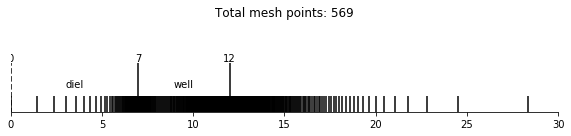

In [5]:
m.plot_mesh()
plt.xlim(0,30)

In [6]:
m.ensure_function_exists("p",value=0)
m.ensure_function_exists("n",value=0)
m.ensure_function_exists("pderiv",value=0)
m.ensure_function_exists("nderiv",value=0)
m.ensure_function_exists("fc",value=0)

In [7]:
idw=m.interfaces_point[0][0]
m.fc[idw]=5.25e13/(1e7)**2/m.dzm[idw]

In [8]:
_,shm,scm=m.submesh_cover([7*nm,20*nm])

In [9]:
#Equilibrium(m)
Linear_Fermi(m,contacts={'gate':0,'idw':1,'source':2,'subs':3}).solve(**dict(gate=-5,idw=0,source=0,subs=0))
psm=PoissonSolver(m)
sc=SelfConsistentLoop(fieldsolvers=[psm],carriersolvers=[Schrodinger(shm),Semiclassical(scm)],)

In [10]:
sc.ramp_epsfactor(start=1e3,max_iter=20,dlefmin=.005)

Starting eps factor ramp from 1000 to 1
  Eps factor: 1.00e+03
  Starting SC loop
    iter:   0  err: 1.93e-01  activ: 1
    iter:   1  err: 1.90e-02  activ: 1
    iter:   2  err: 2.35e-04  activ: 1
    iter:   3  err: 7.02e-08  activ: 1
    Loop finished in  4 iterations with err=7.02367e-08
  Eps factor: 6.31e+02
  Starting SC loop
    iter:   0  err: 4.63e-02  activ: 1
    iter:   1  err: 1.78e-03  activ: 1
    iter:   2  err: 2.64e-06  activ: 1
    iter:   3  err: 1.33e-09  activ: 1
    Loop finished in  4 iterations with err=1.32893e-09
  Eps factor: 2.51e+02
  Starting SC loop
    iter:   0  err: 9.49e-02  activ: 1
    iter:   1  err: 7.54e-03  activ: 1
    iter:   2  err: 6.90e-05  activ: 1
    iter:   3  err: 3.31e-08  activ: 1
    Loop finished in  4 iterations with err=3.31068e-08
  Eps factor: 7.94e+01
  Starting SC loop
    iter:   0  err: 1.56e-01  activ: 1
    iter:   1  err: 7.88e-03  activ: 1
    iter:   2  err: 2.47e-04  activ: 1
    iter:   3  err: 3.06e-07  activ: 1


In [11]:
if 1:
    mbkp=MultibandKP(shm,ktmax=2.5,num_kpoints=30)
    # This is some sort of boundary condition not sure what... not huge effect on density
    for H in mbkp._H:
        H[:6,:6]*=2
        H[-6:,-6:]*=2
    scl=SelfConsistentLoop(fieldsolvers=[psm],carriersolvers=[mbkp,Semiclassical(shm,'electron'),Semiclassical(scm)])
    scl.loop(tol=1e-8)

Assembling k.p matrices ...
Done assembly.
Starting SC loop
  iter:   0  err: 9.12e-02  activ: 1
  iter:   1  err: 1.25e-02  activ: 1
  iter:   2  err: 1.09e-03  activ: 1
  iter:   3  err: 1.16e-04  activ: 1
  iter:   4  err: 2.91e-05  activ: 1
  iter:   5  err: 7.21e-06  activ: 1
  iter:   6  err: 1.81e-06  activ: 1
  iter:   7  err: 4.58e-07  activ: 1
  iter:   8  err: 1.16e-07  activ: 1
  iter:   9  err: 2.94e-08  activ: 1
  iter:  10  err: 7.46e-09  activ: 1
  Loop finished in 11 iterations with err=7.46235e-09


In [12]:
mon.p.integrate(definite=True)/(1/cm**2)/1e13

Function(1.294325865477748)

# Make GOMAC FIG

In [13]:
import matplotlib.pyplot as plt
import numpy as np
#from jxhfet.util import oldcolors; oldcolors()
from matplotlib.transforms import Bbox
from matplotlib.patches import Rectangle,Ellipse,Polygon
from matplotlib.lines import Line2D
from matplotlib.collections import PatchCollection
import matplotlib.transforms as transforms
from cycler import cycler

In [14]:
plt.rcParams['axes.linewidth']=3
plt.rcParams['lines.linewidth']=3
plt.rcParams['font.family']='sans-serif'
plt.rcParams['font.sans-serif']=['STIX']
plt.rcParams['mathtext.fontset']='stix'
plt.rcParams['font.size']=16
plt.rcParams['axes.prop_cycle'] = cycler(color='bgrcmyk')

## BD

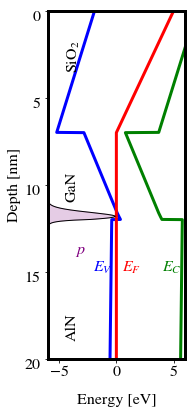

In [15]:
def fig_pFET_bd(ax):
    ax.plot(m.Ev,m.zp)
    ax.plot(m.Ec,m.zp)
    ax.plot(m.EF,m.zp)
    ax.set_yticks(np.linspace(0,20,5))
    ax.set_ylim(20,0)
    ax.set_ylabel("Depth [nm]")
    #plt.gca().yaxis.set_label_position("right")
    #plt.gca().yaxis.tick_right()
    ax.set_xlim(-6,6)
    plt.setp(ax.get_yticklabels(),va='top')
    #plt.gca().add_artist(Ellipse((-4,5.5),3,6,facecolor='none',edgecolor='k'))
    #plt.gca().add_artist(Ellipse((5,5.5),3,6,facecolor='none',edgecolor='k'))
    
    ax.set_xlabel("Energy [eV]")
    ax.xaxis.set_label_coords(.5,-.1)
    ax.text(4,15,"$E_C$",color='g',transform=ax.transData)
    ax.text(-2,15,"$E_V$",color='b',transform=ax.transData)
    ax.text(.5,15,"$E_F$",color='r',transform=ax.transData)
    
    ax2=ax.twiny()
    xmax=500
    ax2.plot(m.p*(1e7)**3/1e18,m.zp,'k',linewidth=1)
    ax2.fill_betweenx(m.zp,m.p*(1e7)**3/1e18,color='purple',alpha=.2)
    ax2.set_xlim(0,xmax)
    ax2.set_xticks([])
    ax2.text(100,14,"$p$",color='purple',transform=ax2.transData)

    if 0:
        hl=nno.read(nno.dir+"/densities/density1Dhl"+suffix+".dat")
        el=nno.read(nno.dir+"/densities/density1Del"+suffix+".dat")
        ax2.plot(hl['hl[1e18/cm3]'],hl['position[nm]'],'k',linewidth=1)
        ax2.plot(xmax-el['el[1e18/cm3]'],el['position[nm]'],'k',linewidth=1)
        ax2.fill_betweenx(hl['position[nm]'],hl['hl[1e18/cm3]'],color='purple',alpha=.2)
        ax2.fill_betweenx(el['position[nm]'],xmax-el['el[1e18/cm3]'],x2=xmax,color='orange',alpha=.6)
        ax2.set_xlim(0,xmax)
        ax2.set_xticks([])
        ax2.text(100,14,"$p$",color='purple',transform=ax2.transData)
        #print("hl {:.2g}x10^13/cm^2".format(np.trapz(hl['hl[1e18/cm3]']*1e18*1e-7,hl['position[nm]'])/1e13))
        #print("el {:.2g}x10^13/cm^2".format(np.trapz(el['el[1e18/cm3]']*1e18*1e-7,el['position[nm]'])/1e13))

    ax2.text(.13,.05,"AlN",transform=ax2.transAxes, rotation=90, ha='left', va='bottom')
    ax2.text(.13,.45,"GaN",transform=ax2.transAxes, rotation=90, ha='left', va='bottom')
    ax2.text(.13,.82,"SiO$_2$",transform=ax2.transAxes, rotation=90, ha='left', va='bottom')

fig=plt.figure(figsize=(3,6),frameon=False)
ax=plt.subplot(111)
fig_pFET_bd(ax)
plt.tight_layout()    
plt.savefig('pFET_bd.png')

## disp

In [16]:
from scipy import gradient
from scipy.interpolate import interp1d
from matplotlib.transforms import Bbox

In [17]:
def DOS_of_one(k_t,bs1_t,E):
    kt2=np.ravel(interp1d(np.ravel(bs1_t),np.ravel(k_t)**2,fill_value=0,bounds_error=False,kind='quadratic')(E))
    N=1/(2*np.pi)**2 * np.pi *kt2
    DOS=gradient(N,E[1]-E[0])
    return -DOS
E=np.linspace(.1,-.1,1200)
DOS=0

-1.10522783612e+13
-1.67788816217e+12


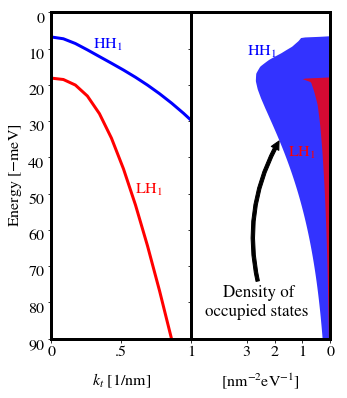

In [18]:
def fig_pFET_disp(ax):

    ax.axis('off')
    ax1=plt.axes(Bbox.from_extents(0,0,.5,1).transformed(ax.transAxes+ax.figure.transFigure.inverted()))
    ax2=plt.axes(Bbox.from_extents(.5,0,1,1).transformed(ax.transAxes+ax.figure.transFigure.inverted()),sharey=ax1)
    
    ### Dispersion plot
    
    # Plot the first two levels
    k1,e1=mbkp._kt,mbkp._mesh.kpen[:,0,0]
    ax1.plot(k1,-e1*1e3,'b',label="HH-1")
    k3,e3=mbkp._kt,mbkp._mesh.kpen[:,2,0]
    ax1.plot(k3,-e3*1e3,'r',label="LH-1")
    
    # Also plot the next level to make sure it's offscreen!
    #ax1.plot(disp_hg['k[1/nm]'],disp_hg['ev_5[eV]']*1e3,'b',label="HH-2")
    
    # Extract DOS
    DOS1=2*DOS_of_one(k1,e1,E)
    DOS3=2*DOS_of_one(k3,e3,E)
    
    # Label bands
    ax1.text(.3,10,r"HH$_1$",color='b',transform=ax1.transData)
    ax1.text(.6,50,r"LH$_1$",color='r',transform=ax1.transData)
    #ax1.text(.4,-8,r"$E_F$",color='k',transform=ax1.transData)
    ax1.axhline(0,linestyle='--',color='k')
    
    # Label axes
    ax1.yaxis.set_label_text(r"Energy [$-$meV]")
    #ax1.yaxis.set_label_coords(-.2,.72)
    ax1.xaxis.set_label_text(r"$k_t$ [1/nm]")
    ax1.xaxis.set_label_coords(.5,-.1)
    plt.setp(ax1.get_yticklabels(),va='top')
    
    # Set limits and ticks
    ax1.set_ylim(90,0);
    ax1.set_xlim(0,1)
    ax1.set_xticks([0,.5,1])
    ax1.set_xticklabels(["0",".5","1"])

    ### DOS plot
    
    # Plot occupieds
    ax2.fill_betweenx(-E*1e3,DOS1*(1/(1+np.exp(-E/.026))),0,facecolor='b',edgecolor='k',linewidth=0,alpha=.8,label='HH-1')
    ax2.fill_betweenx(-E*1e3,(DOS3)*(1/(1+np.exp(-E/.026))),0,facecolor='r',edgecolor='k',linewidth=0,alpha=.8,label='LH-1')
    ax2.axhline(0,linestyle='--',color='k')
    
    # Label and set limits
    ax2.set_xlim(5,0)
    ax2.set_xticks([0,1,2,3])
    ax2.set_xlabel("[nm$^{-2}$eV$^{-1}$]")
    ax2.xaxis.set_label_position("bottom")
    ax2.xaxis.tick_bottom()
    ax2.xaxis.set_label_coords(.5,-.1)
    plt.setp(ax2.get_yticklabels(),visible=False)

    # Label DOSs
    plt.text(3,12,r"HH$_1$",color='b')
    plt.text(1.5,40,r"LH$_1$",color='r')

    plt.annotate("Density of\noccupied states ",(1.8,35),xytext=(2.57,80),ha='center',va='center',fontsize=17,
                 arrowprops=dict(arrowstyle='simple',color='k',connectionstyle='arc3,rad=-.2',relpos=(.5,1)))

    print(np.trapz(DOS1*(1/(1+np.exp(-E/.026))),E)*1e14)
    print(np.trapz(DOS3*(1/(1+np.exp(-E/.026))),E)*1e14)
    
fig=plt.figure(figsize=(5,6),frameon=False)
ax=plt.subplot(111)
fig_pFET_disp(ax)
#plt.tight_layout()
plt.savefig("pFET_disp.png")

In [19]:
kT=k*shm.T
eta=(shm.kpen-shm.EF)/kT.tpf()
np.trapz(np.sum(1/(2*np.pi)*np.trapz(mbkp._kt*(mbkp._normsqs/(1+np.exp(-eta))).T,x=mbkp._kt),axis=1),shm.zp)

Function(0.12943258670788252)

In [20]:
m.p.integrate(definite=True)

Function(0.12943258654777484)

-1.10522783612e+13
-1.67788816217e+12


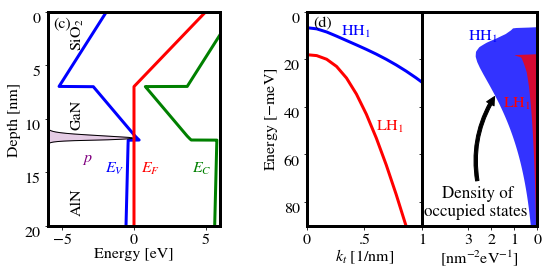

In [23]:
fig=plt.figure(figsize=(8,3.5),frameon=False)
ax1=fig.add_axes(plt.Axes(plt.gcf(),[.1,.15,.3,.85]))
ax2=fig.add_axes(plt.Axes(plt.gcf(),[.55,.15,.4,.85]))
fig_pFET_bd(ax1)
fig_pFET_disp(ax2)
ax1.text(.03,.93,"(c)",transform=ax1.transAxes)
ax2.figure.axes[-1].text(.03,.93,"(d)",transform=ax2.transAxes)
plt.savefig("pFET_theory.png")